# EQ/IR Conditional European: Calls, Puts × CMS Above/Below

Pricing and risk for a vanilla equity payoff *gated by a rates condition* — an SPX call that only pays if 10y CMS fixes above 4%. The general payoff at maturity is:

$$ V_T = \max\!\big(\eta_S\,(S_T - K),\; 0\big) \cdot \mathbf{1}\{\eta_R\,(R_T - B) > 0\} $$

where $S$ = SPX, $R$ = the 10y CMS rate fixing at $T$, $K$ = equity strike, $B$ = rate barrier. The signs $\eta_S, \eta_R \in \{+1, -1\}$ select four variants:

| Variant | $\eta_S$ | $\eta_R$ | Payoff |
|---------|---------|---------|--------|
| Call × Above | +1 | +1 | $\max(S_T-K,0) \cdot \mathbf{1}\{R_T > B\}$ |
| Call × Below | +1 | -1 | $\max(S_T-K,0) \cdot \mathbf{1}\{R_T < B\}$ |
| Put × Above  | -1 | +1 | $\max(K-S_T,0) \cdot \mathbf{1}\{R_T > B\}$ |
| Put × Below  | -1 | -1 | $\max(K-S_T,0) \cdot \mathbf{1}\{R_T < B\}$ |

## What changes versus EQ/FX, and what doesn't

**Doesn't change:** the closed form. The conditioning leg enters through exactly two scalars — a standardised threshold $h$, and the shift $h$ picks up when the numeraire changes from cash to the equity. That shift is $\rho\sigma_S\sqrt{T}$ *regardless of the leg's dynamics*, because it acts on the standard normal driving the condition, not on the observable. So the same bivariate normal machinery prices both.

**Does change:** three things, all of which matter more than the formula.

1. **The rate is normal, not lognormal.** Market convention for swaption and CMS vol has been Bachelier since ~2015; it also survives zero and negative rates. So $h$ has no log and no $-\tfrac12\sigma^2T$:
   $$h_{\text{FX}} = \frac{\ln(X_0/B) + (\mu_X - \tfrac12\sigma_X^2)T}{\sigma_X\sqrt{T}} \qquad\qquad h_{\text{CMS}} = \frac{R_{\text{adj}} - B}{\sigma_R\sqrt{T}}$$
2. **CMS needs a convexity adjustment.** A swap rate is a martingale under the *annuity* measure, not the $T$-forward measure we price in, so $\mathbb{E}^T[R_T] \neq R_0$. Skipping this is not a rounding error — see §4.
3. **Risk is quoted differently.** DV01 per basis point, vega per bp of *normal* vol. Not delta per 1% spot move.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from src.hybrid import (EQIRTrade, EquityLeg, RateCondition,
                        conditional_european, conditional_european_mc,
                        convexity_adjustment)
from src.hybrid.eqir import greeks

In [2]:
# --- Trade attributes (defined inline, self-contained) ---
NOTIONAL = 100e6   # $100mm
T = 2.0            # 2y to the CMS fixing

t = EQIRTrade(
    F=7200.0 * np.exp((0.045 - 0.015) * T),  # SPX forward to T (spot 7200, r 4.5%, q 1.5%)
    K=7200.0,        # SPX strike (= spot, so ITM on the forward)
    P0T=np.exp(-0.045 * T),                  # USD discount factor to T
    sig_S=0.16,      # vol of the SPX FORWARD (see note below)
    R_0=0.0410,      # 10y forward swap rate, 2y forward -- UNADJUSTED
    B=0.0410,        # rate barrier set at the forward (ATM-barrier)
    sig_R=0.0080,    # swap-rate normal vol, 80bp/yr
    T=T,
    rho=-0.30,       # SPX / CMS10 correlation
    tenor=10,        # CMS10
    freq=2,          # semiannual swap
)

print(f"Notional:    ${NOTIONAL/1e6:.0f}mm")
print(f"SPX:         forward {t.F:.0f}, strike {t.K:.0f}  ({(t.F/t.K-1)*100:+.1f}% relative to strike)")
print(f"CMS10:       forward swap {t.R_0:.3%}, barrier {t.B:.3%}")
print(f"             convexity-adjusted {t.R_adj:.4%}  (+{(t.R_adj-t.R_0)*1e4:.2f}bp)")
print(f"Tenor:       {t.T}y")
print(f"Vols:        sig_S={t.sig_S:.0%} (equity, relative), sig_R={t.sig_R*1e4:.0f}bp/yr (rate, normal)")
print(f"Discounting: P(0,T)={t.P0T:.4f}")
print(f"Corr:        rho={t.rho}")

Notional:    $100mm
SPX:         forward 7645, strike 7200  (+6.2% relative to strike)
CMS10:       forward swap 4.100%, barrier 4.100%
             convexity-adjusted 4.1445%  (+4.45bp)
Tenor:       2.0y
Vols:        sig_S=16% (equity, relative), sig_R=80bp/yr (rate, normal)
Discounting: P(0,T)=0.9139
Corr:        rho=-0.3


**A note on $\sigma_S$.** We price under the $T$-forward measure, where the martingale is the *forward*, so $\sigma_S$ is the volatility of $F(T)$ — not of spot. The two coincide only when rates are deterministic, which is precisely the assumption an EQ/IR hybrid abandons. For a 2y trade the difference is second-order, but it is a genuine input adjustment rather than a relabelling, and it grows with maturity and rate vol.

Taking $P(0,T)$ and $F(T)$ as market observables (rather than deriving them from a flat $r$) is what makes the model self-consistent once the payoff is conditioned on a rate.

## Summary table — prices and risk across the four variants

In [3]:
variants = [("call", "above"), ("call", "below"), ("put", "above"), ("put", "below")]
units = NOTIONAL / t.F   # SPX-forward notional

print(f"{'Variant':<18} {'Price':>9} {'Premium $mm':>12} "
      f"{'delta_eq':>9} {'vega_eq $k':>11} {'DV01 $k':>9} "
      f"{'rate_vega $k':>13} {'cega $k':>9}")
print("-" * 108)
for eq, cd in variants:
    tv = replace(t, eq_type=eq, cond_dir=cd)
    g = greeks(tv)
    sign = ">" if cd == "above" else "<"
    label = f"{eq:>4} x R {sign} B"
    print(f"{label:<18} {tv.price():9.2f} {tv.price()*units/1e6:12.2f} "
          f"{g['delta_eq']:9.4f} {g['vega_eq']*units/1e3:11.1f} "
          f"{g['dv01']*units/1e3:9.1f} {g['rate_vega']*units/1e3:13.1f} "
          f"{g['cega']*units/1e3:9.1f}")

Variant                Price  Premium $mm  delta_eq  vega_eq $k   DV01 $k  rate_vega $k   cega $k
------------------------------------------------------------------------------------------------------------
call x R > B          308.17         4.03    0.2479       156.4      37.3           2.1      53.7
call x R < B          527.61         6.90    0.3438       323.6     -37.3          -2.1     -53.7
 put x R > B          287.52         3.76   -0.1987       311.0      18.5           1.0     -28.8
 put x R < B          141.36         1.85   -0.1236       169.0     -18.5          -1.0      28.8


**Read.** Risk is on the full \$100mm notional. **DV01 flips sign with $\eta_R$** — a call gated on rates *above* the barrier gains when rates rise; gated *below*, it loses. **Cega flips with $\eta_S\eta_R$**, exactly as in the FX case. Note the equity risk (`delta_eq`, `vega_eq`) is roughly halved versus a vanilla, because the condition only pays out about half the time.

## Payoff at maturity

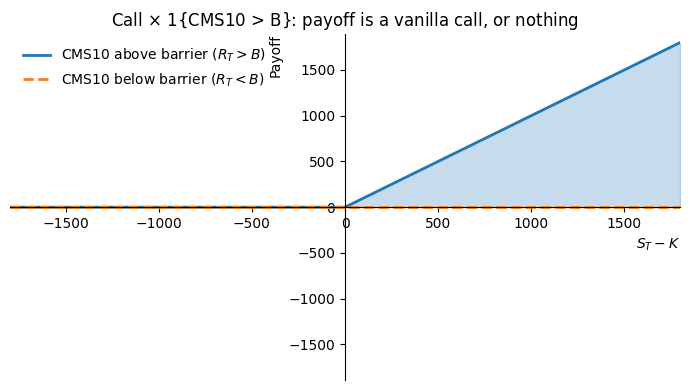

In [4]:
half_range = 1800
x = np.linspace(-half_range, half_range, 300)   # x = S_T - K, origin at strike
payoff_above = np.maximum(x, 0.0)               # CMS above barrier -> vanilla call
payoff_below = np.zeros_like(x)                 # CMS below barrier -> nothing
ymax = half_range * 1.05

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x, 0, payoff_above, color="C0", alpha=0.25)
ax.plot(x, payoff_above, color="C0", linewidth=2, label="CMS10 above barrier ($R_T > B$)")
ax.plot(x, payoff_below, color="C1", linewidth=2, linestyle="--", label="CMS10 below barrier ($R_T < B$)")
ax.set_xlim(-half_range, half_range); ax.set_ylim(-ymax, ymax)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.set_xlabel("$S_T - K$", loc="right"); ax.set_ylabel("Payoff", loc="top")
ax.set_title("Call $\\times$ 1{CMS10 > B}: payoff is a vanilla call, or nothing")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

The payoff is *discontinuous in the rate*: cross the barrier and the entire equity option switches on. That is where the correlation risk comes from — the two legs are not separable.

## The convexity adjustment

A CMS rate is not a martingale under the $T$-forward measure. Writing the swap's annuity as a function of a flat yield,

$$G(y) = \sum_{i=1}^{n}\frac{\delta}{(1+\delta y)^i}, \qquad \delta = 1/\text{freq}$$

the second-order expansion of the measure change gives

$$\mathbb{E}^T[R_T] \approx R_0 - \tfrac{1}{2}\,\sigma_R^2\, T\, \frac{G''(R_0)}{G'(R_0)}$$

$G$ is decreasing and convex ($G' < 0$, $G'' > 0$), so **the adjustment is always positive**. Intuitively: the annuity is worth less in high-rate states, so under $\mathbb{Q}^T$ those states carry more weight than under the annuity measure.

In [5]:
print(f"{'':22} {'CMS2':>10} {'CMS5':>10} {'CMS10':>10} {'CMS30':>10}")
print("-" * 66)
for Tf in (1.0, 2.0, 5.0, 10.0):
    row = [convexity_adjustment(t.R_0, Tf, t.sig_R, tn, 2) * 1e4
           for tn in (2, 5, 10, 30)]
    print(f"  fixing in {Tf:4.1f}y      " + "".join(f"{v:9.2f}bp" for v in row))

print()
print("Scaling: linear in T, quadratic in vol, increasing in tenor.")
print(f"  base case (CMS10, {t.T:.0f}y, {t.sig_R*1e4:.0f}bp): "
      f"{convexity_adjustment(t.R_0, t.T, t.sig_R, 10, 2)*1e4:.2f}bp")
print(f"  double the vol:                   "
      f"{convexity_adjustment(t.R_0, t.T, 2*t.sig_R, 10, 2)*1e4:.2f}bp  (4x)")

                             CMS2       CMS5      CMS10      CMS30
------------------------------------------------------------------
  fixing in  1.0y           0.62bp     1.23bp     2.22bp     5.79bp
  fixing in  2.0y           1.25bp     2.47bp     4.45bp    11.58bp
  fixing in  5.0y           3.12bp     6.17bp    11.12bp    28.94bp
  fixing in 10.0y           6.24bp    12.35bp    22.24bp    57.88bp

Scaling: linear in T, quadratic in vol, increasing in tenor.
  base case (CMS10, 2y, 80bp): 4.45bp
  double the vol:                   17.79bp  (4x)


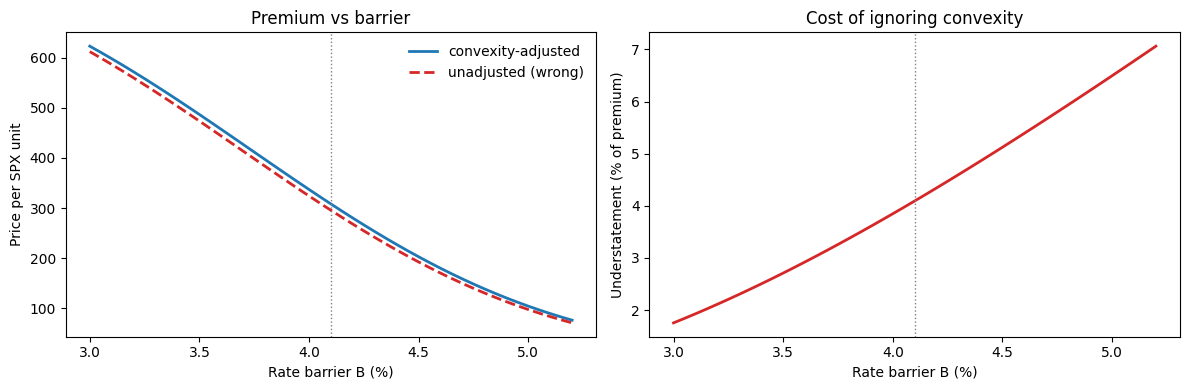

At the ATM barrier B=4.10%: adjusted 308.17 vs unadjusted 295.56  ->  understated by 4.1%


In [6]:
# What ignoring convexity costs, across barrier levels.
eq_leg, _ = t.legs()
barriers = np.linspace(0.030, 0.052, 45)
adj, naive = [], []
for B in barriers:
    tb = replace(t, B=B)
    adj.append(tb.price())
    naive.append(conditional_european(
        eq_leg, RateCondition(R_adj=t.R_0, B=B, sig_R=t.sig_R),
        t.T, t.rho, "call", "above")["price"])
adj, naive = np.array(adj), np.array(naive)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(barriers*100, adj, color="C0", linewidth=2, label="convexity-adjusted")
ax1.plot(barriers*100, naive, color="C3", linewidth=2, linestyle="--", label="unadjusted (wrong)")
ax1.axvline(t.R_0*100, color="grey", linestyle=":", linewidth=1)
ax1.set_xlabel("Rate barrier B (%)"); ax1.set_ylabel("Price per SPX unit")
ax1.set_title("Premium vs barrier"); ax1.legend(frameon=False)

ax2.plot(barriers*100, (adj-naive)/adj*100, color="C3", linewidth=2)
ax2.axvline(t.R_0*100, color="grey", linestyle=":", linewidth=1)
ax2.set_xlabel("Rate barrier B (%)"); ax2.set_ylabel("Understatement (% of premium)")
ax2.set_title("Cost of ignoring convexity")
plt.tight_layout(); plt.show()

i = np.argmin(abs(barriers - t.B))
print(f"At the ATM barrier B={barriers[i]:.2%}: adjusted {adj[i]:.2f} vs "
      f"unadjusted {naive[i]:.2f}  ->  understated by {(adj[i]-naive[i])/adj[i]:.1%}")

**Read.** A 4.45bp shift in the rate is worth a few percent of premium — and the *relative* error grows as the barrier moves out of the money, because there you are pricing the tail of the rate distribution, where a shift of the mean matters proportionally more. This is why `RateCondition.from_forward_swap()` exists: it takes the raw forward swap rate and adjusts internally, so the adjustment cannot be silently skipped.

The approximation uses a single vol, so it cannot see the smile. Against full static replication over a swaption cube, expect a few tenths of a bp to a few bp of difference, growing with maturity, tenor and skew steepness.

## Pricing the four variants (closed form + Monte Carlo)

In [7]:
eq_leg, cms_leg = t.legs()
print(f"{'Variant':<18} {'Closed form':>13} {'Monte Carlo':>13} {'MC 95% CI':>26} {'diff/SE':>9}")
print("-" * 84)
for eq, cd in variants:
    cf = conditional_european(eq_leg, cms_leg, t.T, t.rho, eq, cd)["price"]
    mc = conditional_european_mc(eq_leg, cms_leg, t.T, t.rho, eq, cd,
                                 n_paths=1_000_000, seed=7)
    lo, hi = mc["ci95"]
    sign = ">" if cd == "above" else "<"
    print(f"{eq:>4} x R {sign} B      {cf:13.4f} {mc['price']:13.4f} "
          f"  [{lo:9.3f}, {hi:9.3f}] {abs(cf-mc['price'])/mc['std_error']:9.2f}")

# Identity: above + below = unconditional vanilla
print()
for eq in ("call", "put"):
    up = conditional_european(eq_leg, cms_leg, t.T, t.rho, eq, "above")
    dn = conditional_european(eq_leg, cms_leg, t.T, t.rho, eq, "below")
    resid = up["price"] + dn["price"] - up["vanilla_equivalent"]
    print(f"  {eq:>4}: above + below - vanilla = {resid:+.3e}   "
          f"(vanilla {up['vanilla_equivalent']:.4f})")

Variant              Closed form   Monte Carlo                  MC 95% CI   diff/SE
------------------------------------------------------------------------------------
call x R > B           308.1678      307.9299   [  306.434,   309.426]      0.31
call x R < B           527.6108      527.4127   [  525.313,   529.513]      0.18
 put x R > B           287.5189      287.2815   [  286.112,   288.451]      0.40
 put x R < B           141.3564      141.4345   [  140.636,   142.233]      0.19

  call: above + below - vanilla = +1.592e-12   (vanilla 835.7786)
   put: above + below - vanilla = -7.958e-13   (vanilla 428.8753)


Monte Carlo agrees within a standard error or so across all four, and the parity identity $V_{\text{above}} + V_{\text{below}} = V_{\text{vanilla}}$ holds to machine precision — it must, since $\mathbf{1}\{R>B\} + \mathbf{1}\{R<B\} = 1$ almost surely.

## Closed-form formula

$$V_0 = P(0,T)\Big[\eta_S\,F\, M_2\!\big(\eta_S d_1,\; \eta_R(h+\rho\sigma_S\sqrt{T});\; \eta_S\eta_R\rho\big) \;-\; \eta_S\,K\, M_2\!\big(\eta_S d_2,\; \eta_R h;\; \eta_S\eta_R\rho\big)\Big]$$

with

$$d_1 = \frac{\ln(F/K) + \tfrac12\sigma_S^2 T}{\sigma_S\sqrt{T}}, \qquad d_2 = d_1 - \sigma_S\sqrt{T}, \qquad h = \frac{R_{\text{adj}} - B}{\sigma_R\sqrt{T}}$$

Compare this to the EQ/FX formula in the companion notebook: **it is the same expression**. Only $h$ is computed differently. The $\rho\sigma_S\sqrt{T}$ shift on the first term comes from the numeraire change to the equity, and it is dynamics-independent — which is exactly why one closed form covers both asset classes.

In [8]:
from scipy.stats import norm
sqrtT = np.sqrt(t.T)
d1 = (np.log(t.F/t.K) + 0.5*t.sig_S**2*t.T) / (t.sig_S*sqrtT)
d2 = d1 - t.sig_S*sqrtT
h  = cms_leg.h(t.T)

print(f"  F        = {t.F:10.2f}      K   = {t.K:.0f}")
print(f"  d1       = {d1:10.4f}      d2  = {d2:10.4f}")
print(f"  h        = {h:10.4f}      ->  P(CMS > B) = {norm.cdf(h):.2%}")
print(f"  shift    = {t.rho*t.sig_S*sqrtT:10.4f}      (rho * sig_S * sqrt(T))")
print()
print(f"  Verify h against the definition: "
      f"{(cms_leg.R_adj - t.B)/(t.sig_R*sqrtT):.6f}  vs  {h:.6f}")

  F        =    7645.22      K   = 7200
  d1       =     0.3783      d2  =     0.1520
  h        =     0.0393      ->  P(CMS > B) = 51.57%
  shift    =    -0.0679      (rho * sig_S * sqrt(T))

  Verify h against the definition: 0.039309  vs  0.039309


## Deep dive: call × CMS > B

### DV01 — the exposure a vanilla doesn't have

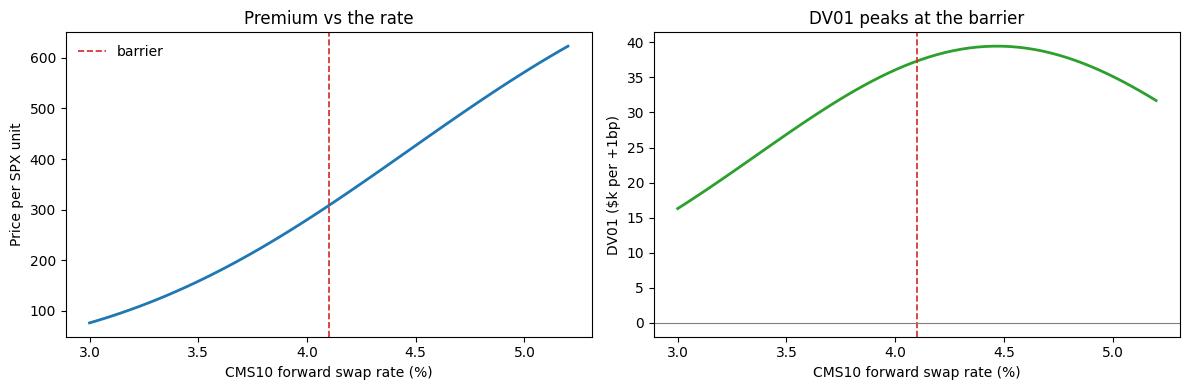

In [9]:
rates = np.linspace(0.030, 0.052, 60)
prices, dv01s = [], []
for R in rates:
    tr = replace(t, R_0=R)
    prices.append(tr.price())
    dv01s.append(greeks(tr)["dv01"] * units / 1e3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(rates*100, prices, color="C0", linewidth=2)
ax1.axvline(t.B*100, color="C3", linestyle="--", linewidth=1.2, label="barrier")
ax1.set_xlabel("CMS10 forward swap rate (%)"); ax1.set_ylabel("Price per SPX unit")
ax1.set_title("Premium vs the rate"); ax1.legend(frameon=False)

ax2.plot(rates*100, dv01s, color="C2", linewidth=2)
ax2.axvline(t.B*100, color="C3", linestyle="--", linewidth=1.2)
ax2.axhline(0, color="grey", linewidth=0.8)
ax2.set_xlabel("CMS10 forward swap rate (%)"); ax2.set_ylabel("DV01 ($k per +1bp)")
ax2.set_title("DV01 peaks at the barrier")
plt.tight_layout(); plt.show()

**Read.** DV01 is largest *at* the barrier, where the rate condition is most uncertain, and decays on both sides as the condition becomes nearly certain to be met or missed. This is digital-like risk: the exposure is to the *probability of crossing*, not to the rate level. A rates desk hedging this with a swap is hedging a position whose DV01 collapses once the market moves away from the barrier.

### Rate vega — the sign flips with the barrier

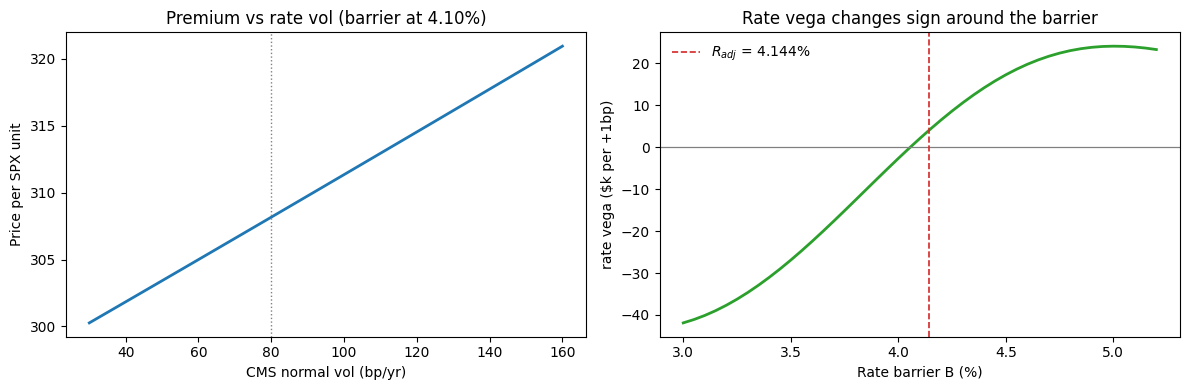

  barrier   P(cond)   rate vega $k
   3.000%    84.41%          -41.9
   3.500%    71.55%          -26.9
   4.100%    51.57%            2.1
   4.800%    28.12%           23.0
   5.200%    17.54%           23.3


In [10]:
vols = np.linspace(0.0030, 0.0160, 60)
p_vol, radj_vol, pcond = [], [], []
for s in vols:
    ts = replace(t, sig_R=s)
    p_vol.append(ts.price())
    radj_vol.append(ts.R_adj*100)
    _, leg = ts.legs()
    pcond.append(norm.cdf(leg.h(ts.T))*100)

barriers2 = np.linspace(0.030, 0.052, 45)
rv, pc = [], []
for B in barriers2:
    tb = replace(t, B=B)
    rv.append(greeks(tb)["rate_vega"] * units / 1e3)
    pc.append(tb.result()["P_condition"] * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(vols*1e4, p_vol, color="C0", linewidth=2)
ax1.axvline(t.sig_R*1e4, color="grey", linestyle=":", linewidth=1)
ax1.set_xlabel("CMS normal vol (bp/yr)"); ax1.set_ylabel("Price per SPX unit")
ax1.set_title(f"Premium vs rate vol (barrier at {t.B:.2%})")

ax2.plot(barriers2*100, rv, color="C2", linewidth=2)
ax2.axhline(0, color="grey", linewidth=0.9)
ax2.axvline(t.R_adj*100, color="C3", linestyle="--", linewidth=1.2,
            label=f"$R_{{adj}}$ = {t.R_adj:.3%}")
ax2.set_xlabel("Rate barrier B (%)"); ax2.set_ylabel("rate vega ($k per +1bp)")
ax2.set_title("Rate vega changes sign around the barrier")
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"{'barrier':>9} {'P(cond)':>9} {'rate vega $k':>14}")
for B in (0.030, 0.035, 0.0410, 0.048, 0.052):
    tb = replace(t, B=B)
    print(f"{B:9.3%} {tb.result()['P_condition']:9.2%} "
          f"{greeks(tb)['rate_vega']*units/1e3:14.1f}")

**Read.** Raising rate vol does two opposing things: it **widens the distribution**, pulling $P(R>B)$ toward 50%, and it **raises $R_{\text{adj}}$** through the $\sigma_R^2$ term in the convexity adjustment.

Dispersion dominates, and it cuts both ways — this is digital vega. When the condition is **in the money** ($B$ below $R_{\text{adj}}$, $P>50\%$), more vol drags the probability down and rate vega is **negative**. When it is **out of the money**, more vol lifts the probability and rate vega is **positive**. The crossing sits just below the adjusted rate rather than exactly at it, because the convexity lift adds a small positive contribution everywhere.

So rate vega is not a fixed-sign Greek. A book of these can be long or short rate vol depending purely on where each barrier sits — which is a genuine trap when aggregating risk.

### Cega — the unhedgeable one

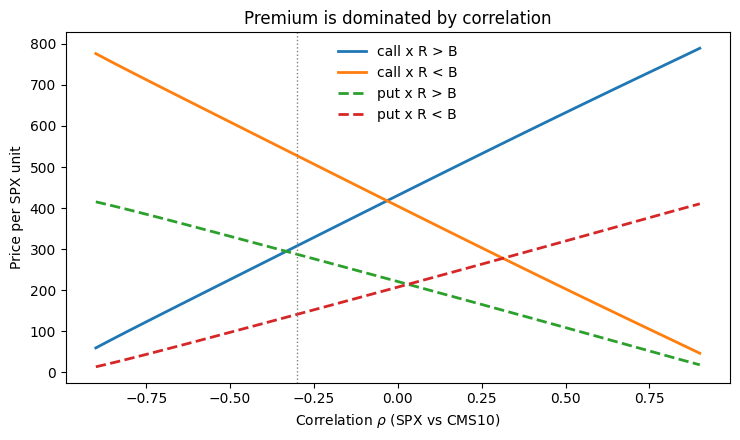

call x R > B:  rho=-0.6 -> 184.92 (-40.0%),  rho=+0.6 -> 672.10 (+118.1%)


In [11]:
rhos = np.linspace(-0.9, 0.9, 60)
by_variant = {}
for eq, cd in variants:
    by_variant[(eq, cd)] = [replace(t, rho=r, eq_type=eq, cond_dir=cd).price()
                            for r in rhos]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for (eq, cd), ys in by_variant.items():
    sign = ">" if cd == "above" else "<"
    style = "-" if eq == "call" else "--"
    ax.plot(rhos, ys, style, linewidth=2, label=f"{eq} x R {sign} B")
ax.axvline(t.rho, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel(r"Correlation $\rho$ (SPX vs CMS10)")
ax.set_ylabel("Price per SPX unit")
ax.set_title("Premium is dominated by correlation")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

base = t.price()
lo = replace(t, rho=-0.6).price(); hi = replace(t, rho=0.6).price()
print(f"call x R > B:  rho=-0.6 -> {lo:.2f} ({lo/base-1:+.1%}),  "
      f"rho=+0.6 -> {hi:.2f} ({hi/base-1:+.1%})")

**Read.** Premium swings by well over 100% across a plausible correlation range. No vanilla instrument carries pure $\rho$ risk, so this cannot be hedged out — it can only be warehoused or crossed against offsetting structures. For EQ/IR the correlation input is also *harder to justify* than in EQ/FX: equity–rate correlation is regime-dependent, flipping sign around inflation-driven versus growth-driven markets.

## How variant choice flips the picture

In [12]:
print(f"{'Variant':<18} {'Price':>9} {'DV01 $k':>10} {'rate_vega $k':>13} "
      f"{'cega $k':>10} {'P(cond)':>9} {'P(joint)':>10}")
print("-" * 84)
for eq, cd in variants:
    tv = replace(t, eq_type=eq, cond_dir=cd)
    g = greeks(tv); r = tv.result()
    sign = ">" if cd == "above" else "<"
    print(f"{eq:>4} x R {sign} B      {tv.price():9.2f} {g['dv01']*units/1e3:10.1f} "
          f"{g['rate_vega']*units/1e3:13.1f} {g['cega']*units/1e3:10.1f} "
          f"{r['P_condition']:9.1%} {r['P_joint_exercise']:10.1%}")

Variant                Price    DV01 $k  rate_vega $k    cega $k   P(cond)   P(joint)
------------------------------------------------------------------------------------
call x R > B         308.17       37.3           2.1       53.7     51.6%      24.1%
call x R < B         527.61      -37.3          -2.1      -53.7     48.4%      31.9%
 put x R > B         287.52       18.5           1.0      -28.8     51.6%      27.5%
 put x R < B         141.36      -18.5          -1.0       28.8     48.4%      16.5%


**Read.** DV01 sign tracks $\eta_R$ alone. Cega sign tracks the product $\eta_S\eta_R$ — a put gated on rates *below* the barrier has the same correlation sign as a call gated *above*, since both pay when the two legs move together.

## Takeaways

1. **The closed form is unchanged from EQ/FX.** Only the standardised threshold $h$ differs — no log, no $-\tfrac12\sigma^2T$ for a normal rate. The numeraire-change shift $\rho\sigma_S\sqrt{T}$ is dynamics-independent, which is what makes one pricer cover both.
2. **Convexity is not optional.** A CMS rate is not a martingale under $\mathbb{Q}^T$; the adjustment is small in basis points but a few percent of premium, and proportionally larger the further the barrier sits out of the money. Prefer `RateCondition.from_forward_swap()` so it cannot be skipped.
3. **DV01 is digital-like** — it peaks at the barrier and decays away from it. Hedging with swaps means holding a hedge whose size collapses as the market moves.
4. **Rate vega changes sign at the barrier.** It is digital vega: negative when the rate condition is in the money, positive when out of the money, crossing just below $R_{\text{adj}}$. Aggregating it across a book without regard to barrier placement is meaningless.
5. **Correlation dominates the price** and cannot be hedged with vanillas — and equity–rate correlation is regime-dependent, so it is a harder mark than the FX analogue.
6. **Use forward-measure inputs.** $\sigma_S$ is the vol of the *forward*, and $P(0,T)$, $F(T)$ should be market observables. Deriving them from a flat short rate contradicts the very thing the payoff is conditioned on.